In [3]:
# ============================================================
# 📦 IMPORTS
# Chargement des bibliothèques
# ============================================================

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
# ============================================================
# 📌 Consignes de la quête
# 
# ============================================================

# 1.Importe cet ensemble de données de tweets dans un DataFrame.
# 2.Ne garde que les tweets positifs et négatifs (tu excluras donc les neutral). Quel est le pourcentage de tweets positifs/négatifs ?
# 3.Copie la colonne text dans une Série X, et la colonne sentiment dans une Série y. Applique un train test split avec le random_state = 32 et un train_size de 0.75.
# 4.Crée un modèle vectorizer avec scikit-learn en utilisant la méthode Countvectorizer. Entraîne ton modèle sur X_train, puis crée une matrice de features X_train_CV. Crée la matrice X_test_CV sans ré-entraîner le modèle. Le format de la matrice X_test_CV doit être 4091x15806 avec 44633 stored elements.
# 5.Entraîne maintenant une régression logistique avec les paramètres par défaut. Tu devrais obtenir les résultats suivants : 0.966pour le test d'entraînement, et 0.877 pour l'ensemble de test.
# 6.Étape bonus : essaye d'afficher 10 tweets qui ont été mal prédits (faux positifs ou faux négatifs). Aurais-tu fait mieux que l'algorithme ?

In [4]:
# ============================================================
# 📂 CHARGEMENT DES DONNÉES
# Lecture et premier aperçu du dataset
# ============================================================

def read_csv(fichier):
    df = pd.read_csv(fichier)
    return df

df = read_csv("train.csv")

In [5]:
# ============================================================
# 🔍 EXPLORATION / EDA
# Analyse exploratoire des données
# ============================================================

def quick_explore(dataframe):
    """Exploration rapide d'un DataFrame"""
    print('##### Observer les lignes #####')
    display(dataframe.head(10))
    print('\n')

    print('##### Dimensions du dataset #####')
    print(f'Lignes : {dataframe.shape[0]}, Colonnes : {dataframe.shape[1]}')
    print('\n')

    print('##### Informations sur les colonnes #####')
    print(dataframe.info())
    print('\n')

    print('##### Noms des colonnes #####')
    print(list(dataframe.columns))
    print('\n')

    print('##### Valeurs uniques #####')
    print(dataframe.nunique())
    print('\n')

    print('##### Description des colonnes numériques #####')
    stats = dataframe.describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).T
    print(stats.to_markdown())
    print('\n')

    print('##### Pourcentage de NaN par colonne #####')
    nan_percentage = (dataframe.isnull().sum() / len(dataframe)) * 100
    only_nan  = nan_percentage[nan_percentage > 0].sort_values(ascending=False)
    print(only_nan)
    print('\n')

    print('##### Nombre de doublons #####')
    print(dataframe.duplicated().sum(), 'doublon(s) trouvé(s)')
    print('\n')

    print('##### NaN par colonne #####')
    print(dataframe.isna().sum())

In [6]:
# ============================================================
# 🔍 EXPLORATION / EDA
# Analyse exploratoire des données
# ============================================================

quick_explore(df)

##### Observer les lignes #####


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive
7,50e14c0bb8,Soooo high,Soooo high,neutral
8,e050245fbd,Both of you,Both of you,neutral
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive




##### Dimensions du dataset #####
Lignes : 27480, Colonnes : 4


##### Informations sur les colonnes #####
<class 'pandas.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27480 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27480 non-null  str  
dtypes: str(4)
memory usage: 858.9 KB
None


##### Noms des colonnes #####
['textID', 'text', 'selected_text', 'sentiment']


##### Valeurs uniques #####
textID           27480
text             27480
selected_text    22463
sentiment            3
dtype: int64


##### Description des colonnes numériques #####
|               |   count |   unique | top                                 |   freq |
|:--------------|--------:|---------:|:------------------------------------|-------:|
| textID        |   27480 |    27480 | cb774db0d1            

In [7]:
# ============================================================
# 📌 Suppression des tweets "neutral"
# Je supprime les tweets neutral et je garde positive et negative
# ============================================================

# Je crée une condition pour garder que les lignes sans neutral
condition = df['sentiment'] != 'neutral'
df_sans_neutral = df[condition]
display(df_sans_neutral['sentiment'].value_counts())

sentiment
positive    8582
negative    7781
Name: count, dtype: int64

In [8]:
# ============================================================
# 📌 Pourcentage des tweets positifs et negatifs
# 
# ============================================================

tweet_positif = df_sans_neutral['sentiment'] == 'positive'
tweet_negatif = df_sans_neutral['sentiment'] == 'negative'

pourcentage_positif = round((len(df_sans_neutral[tweet_positif]) / len(df_sans_neutral['sentiment']) * 100),2)
print(f"Le pourcentage de tweet positif est de {pourcentage_positif}%")

pourcentage_negatif = round((len(df_sans_neutral[tweet_negatif]) / len(df_sans_neutral['sentiment']) * 100),2)
print(f"Le pourcentage de tweet négatif est de {pourcentage_negatif}%")

Le pourcentage de tweet positif est de 52.45%
Le pourcentage de tweet négatif est de 47.55%


In [11]:
# ============================================================
# 📌 Je définis X et y
#  J'applique le train_test_split sur mes features et ma cible
# ============================================================

X = df_sans_neutral['text']
y = df_sans_neutral['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32)

In [14]:
# ============================================================
# 📌 Je crée un modèle CountVectorizer avec la methode CountVectorizer
#  J'entraine mon modèle sur X_train
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
vectorizer.fit(X_train)



,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [15]:
# ============================================================
# 📌 Je crée une matrice de features et ma matrice X_test_CV
#  J'entraine mon X_train et je crée mes matmrices
# ============================================================

X_train_CV = vectorizer.fit_transform(X_train)
X_test_CV = vectorizer.transform(X_test)

print(X_test_CV)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 44633 stored elements and shape (4091, 15806)>
  Coords	Values
  (0, 1462)	0.22708212207612904
  (0, 7575)	0.24704415305619223
  (0, 7883)	0.29421964984936483
  (0, 9812)	0.342270656882441
  (0, 12524)	0.6640924273374673
  (0, 13294)	0.49261520409642334
  (1, 1230)	0.23214915303812425
  (1, 2169)	0.2852775238069251
  (1, 2227)	0.2328007238860219
  (1, 4414)	0.24887315362268742
  (1, 4636)	0.20604444580985107
  (1, 4645)	0.25013172480575974
  (1, 6158)	0.1839687521209241
  (1, 6301)	0.2332402963752713
  (1, 7591)	0.12456177682500827
  (1, 9910)	0.1769094356180966
  (1, 10078)	0.26377369866385014
  (1, 10617)	0.3138111210554935
  (1, 11964)	0.21877302557420195
  (1, 12189)	0.21245829911306963
  (1, 12838)	0.2987212950870301
  (1, 13163)	0.21626400744662574
  (1, 13829)	0.14702189549951092
  (1, 15209)	0.21461526693794244
  (1, 15355)	0.16519286877268302
  :	:
  (4087, 12987)	0.572728356608637
  (4087, 13829)	0.1967579778605289

In [16]:
# ============================================================
# 📌 J'entraine avec une LogisticRegression
# 
# ============================================================

def train_model(X_train, y_train, modele='logistic'):
    """
    Utilisation : model = train_model(X_train, y_train)
    Modeles disponibles : 'logistic', 'decision_tree', 'random_forest', 'linear', 'KNN'
    """
    if modele == 'logistic':
        model = LogisticRegression()
    elif modele == 'decision_tree':
        model = DecisionTreeClassifier()
    elif modele == 'random_forest':
        model = RandomForestClassifier()
    elif modele == 'linear':
        model = LinearRegression()
    elif modele == 'KNN':
        model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    return model

model = train_model(X_train_CV, y_train, modele='logistic')

In [18]:
# ============================================================
# 📌 Le modèle est entrainé
# Maintenant je calcule les scores
# ============================================================

print(f"Le modele obtient un accuracy de {model.score(X_train_CV, y_train)} sur le train et {model.score(X_test_CV, y_test)} sur le test")

Le modele obtient un accuracy de 0.9313070404172099 sur le train et 0.8731361525299438 sur le test


In [19]:
# J'instancie y_pred

y_pred = model.predict(X_test_CV)

# Je vérifie l'ordre des labels pour ma matrice de confusion 

np.unique(y_test)

array(['negative', 'positive'], dtype=object)

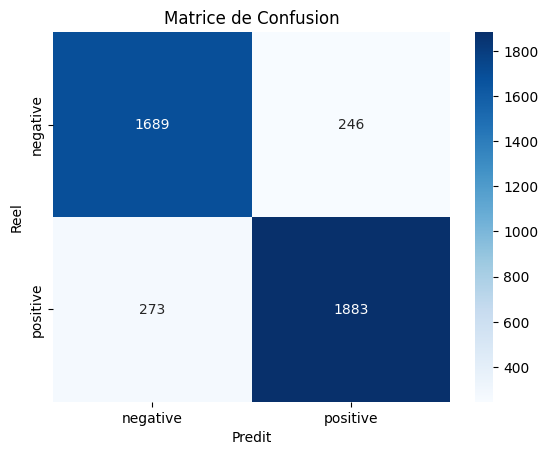

In [20]:
# ============================================================
# 📌 J'affiche une matrice de confusion
# Pour me faire une première idée
# ============================================================

def matrice_confusion(y_test, y_pred, labels=["negative","positive"]):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Non', 'Oui'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predit')
    plt.ylabel('Reel')
    plt.title('Matrice de Confusion')
    plt.show()

matrice_confusion(y_test, y_pred)



In [21]:
# ============================================================
# 📌 J'essaye d'afficher 10 tweets mal prédits
# 
# ============================================================

# Je prends tous les tweets du jeu de test
# où la prédiction EST DIFFÉRENTE de la vraie valeur
erreurs = X_test[y_pred != y_test]

# Je récupère les vraies étiquettes de ces tweets ratés
vrais = y_test[y_pred != y_test]

# Je récupère ce que le modèle a prédit pour ces tweets
predits = y_pred[y_pred != y_test]

# Je crée un tableau avec les 3 infos côte à côte
# pour voir : le tweet | ce qu'il était vraiment | ce que le modèle a cru
df_erreurs = pd.DataFrame({
    'tweet': erreurs.values,
    'reel': vrais.values,
    'predit': predits
})

# J'affiche les 10 premiers
display(df_erreurs.head(10))

,tweet,reel,predit
0,HollowbabesHere comes the utter shite #bgt <I ...,negative,positive
1,SUFFICATION NO BREATHING. It`s okay. There`ll...,negative,positive
2,i wanna vote for Miley Cyrus for the mtv movie...,positive,negative
3,I love music so much that i`ve gone through pa...,negative,positive
4,"I can only message those who message me, if we...",positive,negative
5,"wish I could feel no pain (8) but it`s ok, at...",positive,negative
6,so glad i`m not at uni anymore,positive,negative
7,You`re not here. I hope you`re still resting....,positive,negative
8,"you`re missing out, bb! i`m such a cereal nu...",positive,negative
9,have an amazing time with your mommas tomorro...,negative,positive
